In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
#data collection
df_data = pd.read_csv(r"C:\Users\chaka\Preethu\My_Git_Repo\Ecotype project 3\cleaned_data.csv")
df_data

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type
0,2596,51,3,258.0,0,510,221.0,232,148,6279,Aspen,1,29
1,2590,56,2,212.0,-6,390,220.0,235,151,6225,Aspen,1,29
2,2804,139,9,268.0,65,3180,234.0,238,135,6121,Lodgepole Pine,1,12
3,2785,155,18,242.0,117,3090,238.0,238,122,6211,Lodgepole Pine,1,30
4,2595,45,2,153.0,-1,391,220.0,234,150,6172,Aspen,1,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...
145885,2834,88,8,376.0,44,2552,232.0,227,128,1595,Lodgepole Pine,1,29
145886,2832,68,4,390.0,44,2522,224.0,231,142,1572,Lodgepole Pine,1,29
145887,2829,80,7,390.0,33,2492,229.0,228,133,1550,Lodgepole Pine,1,29
145888,2826,121,7,379.0,30,2462,232.0,234,135,1528,Lodgepole Pine,1,29


In [4]:
df_data.shape

(145890, 13)

In [5]:
df_data.dtypes

Elevation                               int64
Aspect                                  int64
Slope                                   int64
Horizontal_Distance_To_Hydrology      float64
Vertical_Distance_To_Hydrology          int64
Horizontal_Distance_To_Roadways         int64
Hillshade_9am                         float64
Hillshade_Noon                          int64
Hillshade_3pm                           int64
Horizontal_Distance_To_Fire_Points      int64
Cover_Type                             object
Wilderness_Area                         int64
Soil_Type                               int64
dtype: object

In [6]:
#Since no cateogorical feature available, Encoding was not necessary
#SKEW check
columns = ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points']
skewness = df_data[columns].skew()
skewness

Elevation                            -0.664497
Aspect                                0.689432
Slope                                 0.621361
Horizontal_Distance_To_Hydrology      0.792349
Vertical_Distance_To_Hydrology        0.861265
Horizontal_Distance_To_Roadways      -0.058240
Hillshade_9am                        -0.740409
Hillshade_Noon                       -0.505363
Hillshade_3pm                        -0.165213
Horizontal_Distance_To_Fire_Points    0.365249
dtype: float64

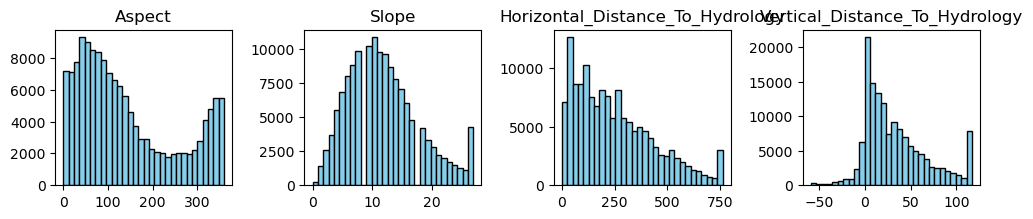

In [7]:
#Columns with skewness within -0.5 to 0.5 are ignored due to lessa impact. 
#rest of the columns are applied with Log Transformation to Positively Skewed Columns more than 0.5 range
pskew_col = ['Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology']
plt.figure(figsize=(10, 4))
for i, col in enumerate(pskew_col, 1):
    plt.subplot(2, 4, i)  # Adjust grid size as needed
    plt.hist(df_data[col], bins=30, color='skyblue', edgecolor='black')
    plt.title(f"{col}")
plt.tight_layout()
plt.show()

Log transformation impacts the skewness to higher values... Since it is a classifier problem, and the skewness are already in moderate range the skew handling is not done. 
The hydrology distance features show positive skew due to natural geographic spread, while slope and aspect are moderately skewed. Since skewness is not extreme, tree-based models can handle them directly without transformation.

EXPLORATORY DATA ANALYSIS

<Axes: xlabel='count', ylabel='Cover_Type'>

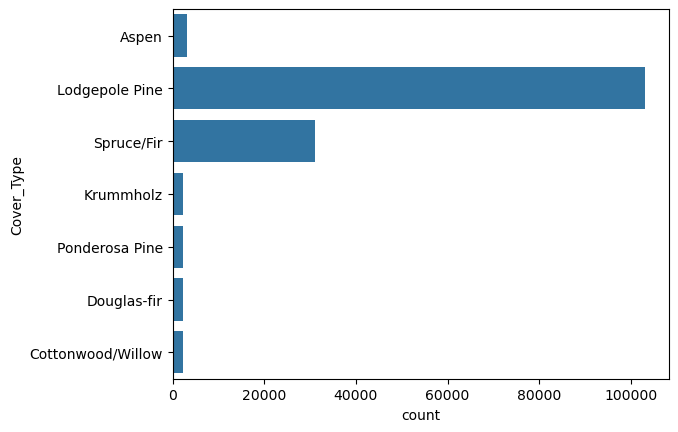

In [18]:
#univariate analysis
#Target column - Cover type
sns.countplot(df_data['Cover_Type']) 

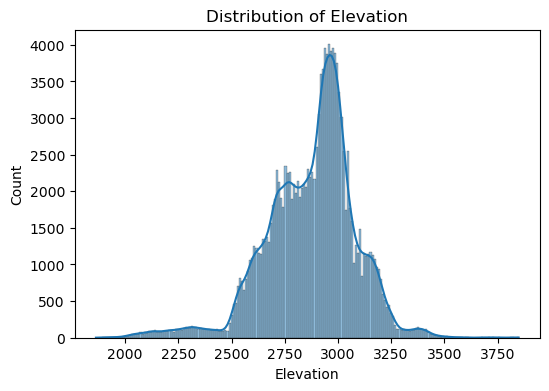

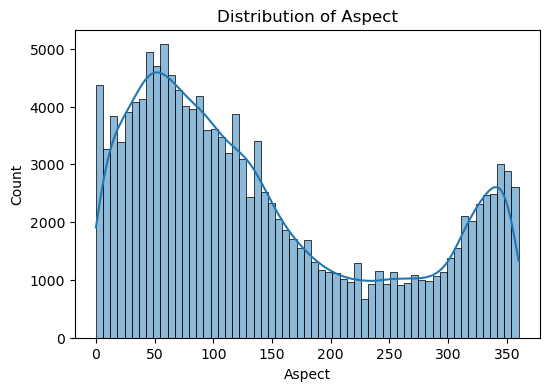

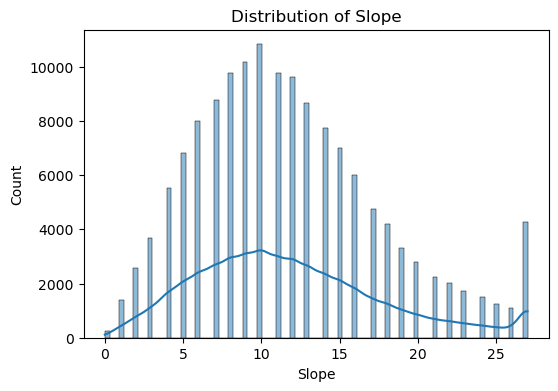

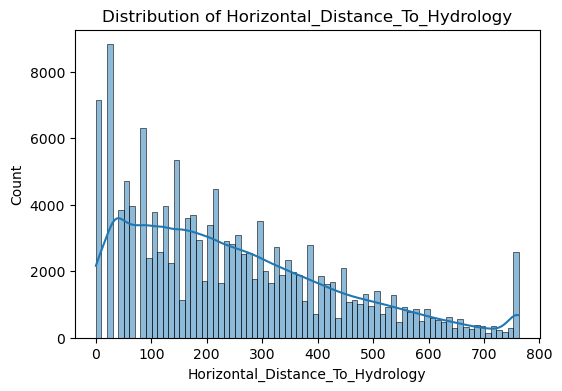

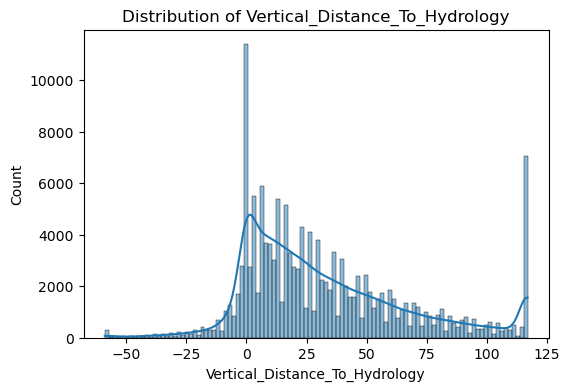

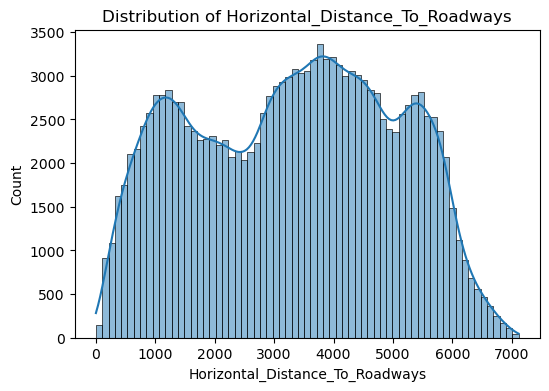

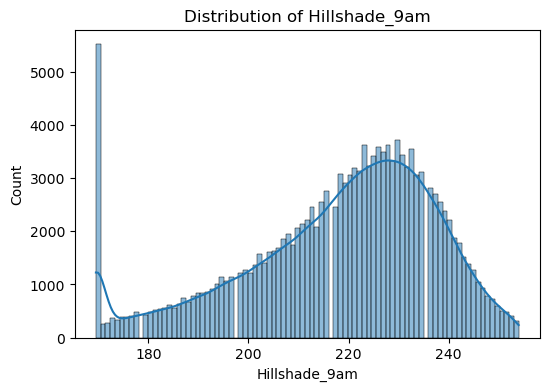

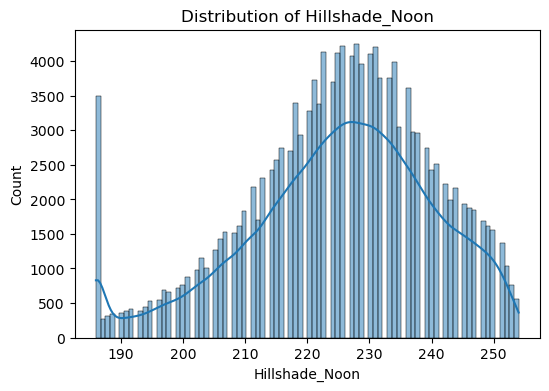

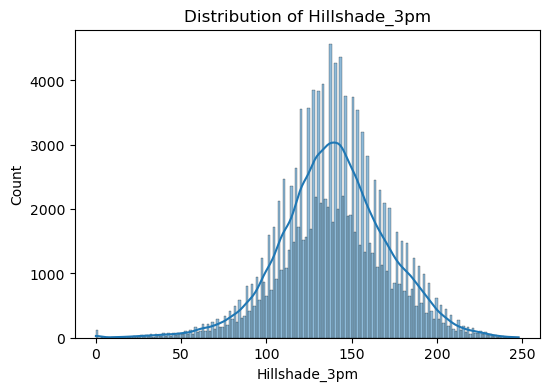

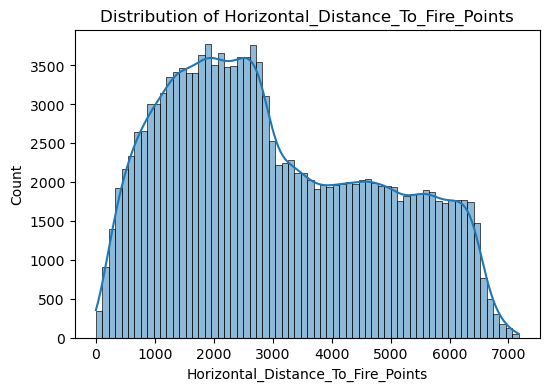

In [28]:
numerical_cols = ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points' ]

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df_data[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

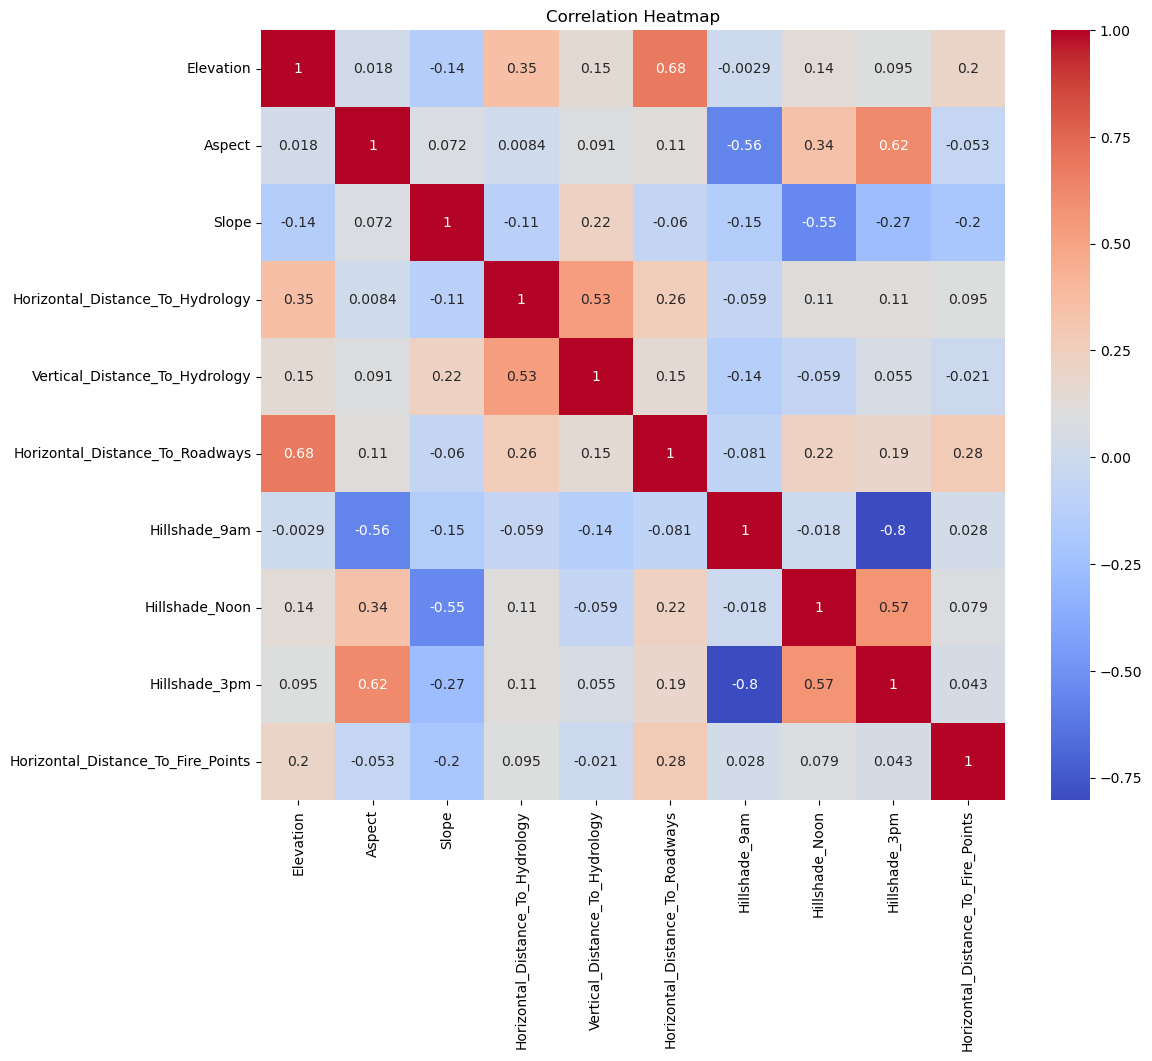

In [30]:
#correlation usinh heat map
plt.figure(figsize=(12,10))
sns.heatmap(df_data[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap shows moderate relationships between some terrain features, particularly among hillshade variables. However, no feature pair exceeds 0.85 correlation, indicating no severe multicollinearity. Therefore, the dataset is suitable for model training, especially for tree-based algorithm

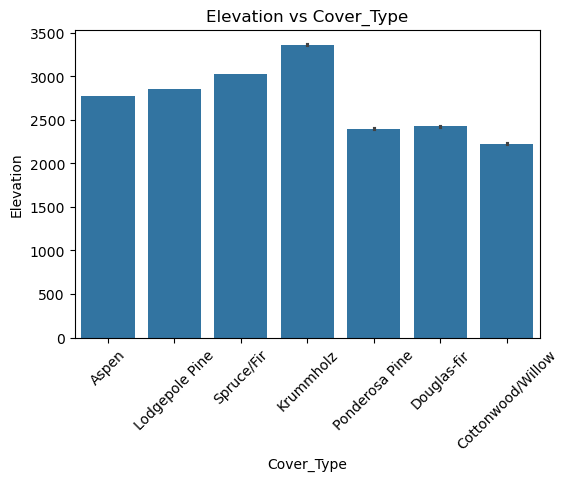

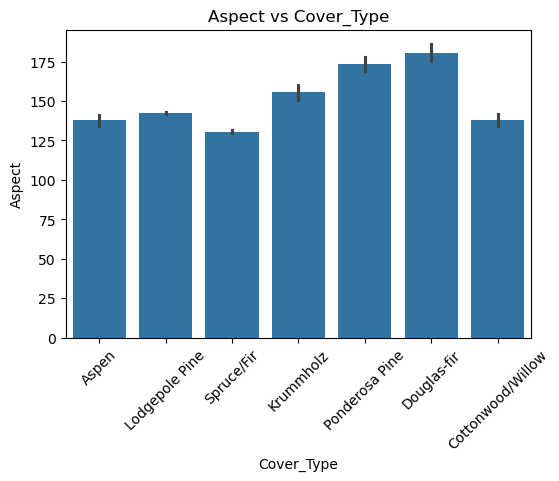

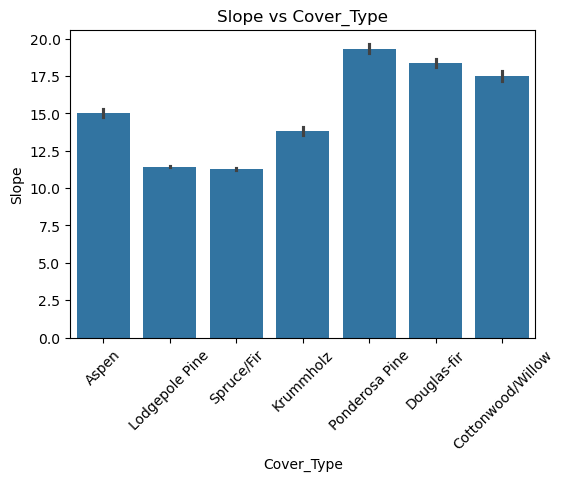

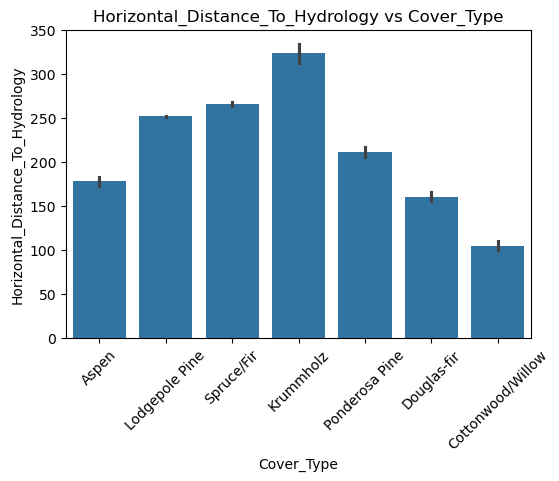

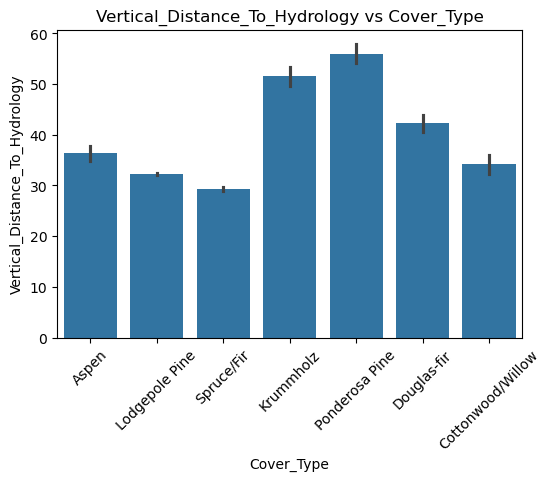

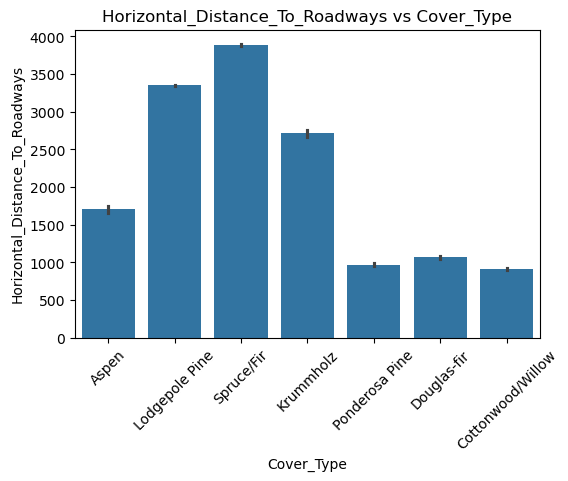

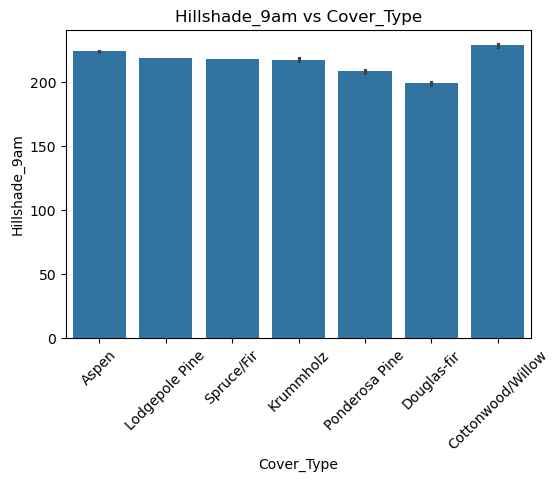

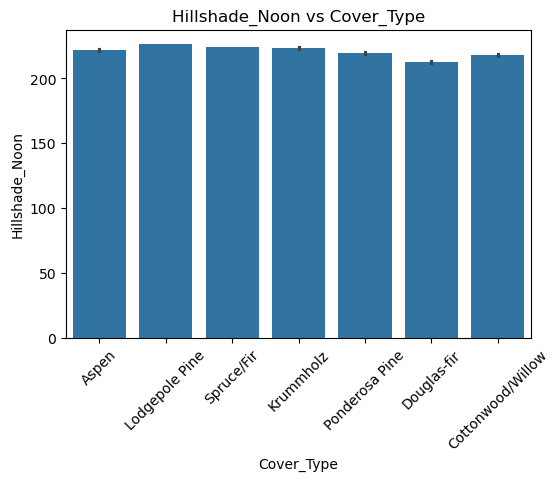

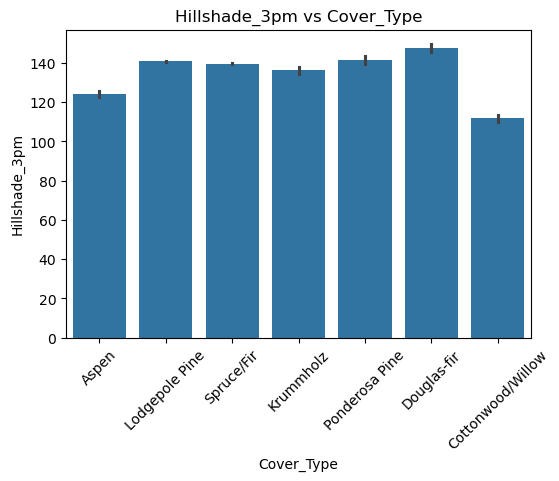

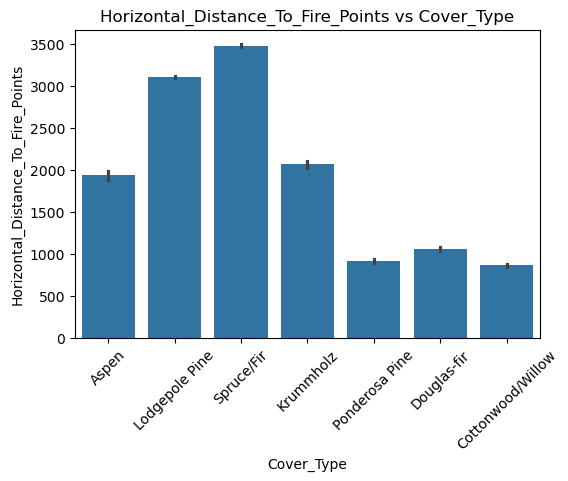

In [39]:
#BIVARIATE ANALYSIS
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.barplot(x=df_data["Cover_Type"], y=df_data[col])
    plt.title(f"{col} vs Cover_Type")
    plt.xticks(rotation=45)
    plt.show()

<Axes: xlabel='Wilderness_Area', ylabel='Cover_Type'>

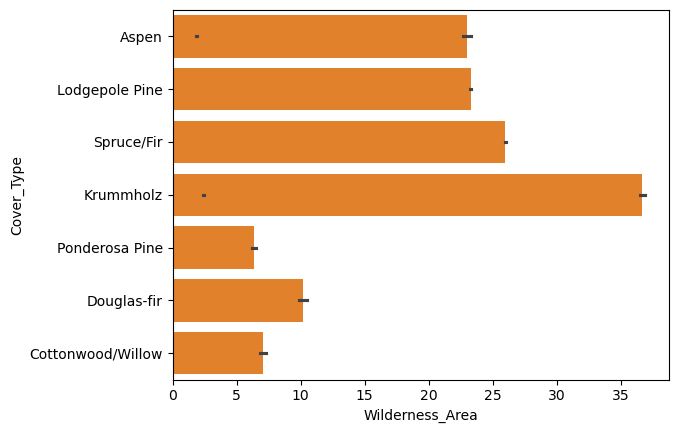

In [ ]:
sns.barplot(data = df_data, x = 'Wilderness_Area', y = 'Cover_Type')

<Axes: xlabel='Soil_Type', ylabel='Cover_Type'>

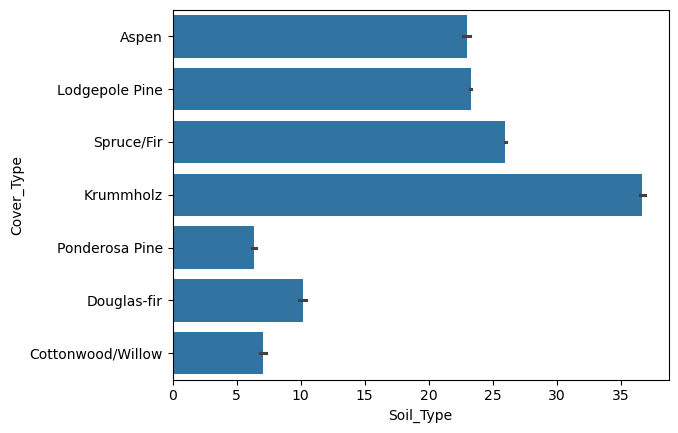

In [43]:
sns.barplot(data = df_data, x = 'Soil_Type', y = 'Cover_Type')

In [40]:
#checking feature score using ANOVA F - test
from sklearn.feature_selection import f_classif

X = df_data.drop("Cover_Type", axis=1) #feature columns
y = df_data["Cover_Type"]              #target columns

f_values, p_values = f_classif(X, y)

feature_scores = pd.DataFrame({
    "Feature": X.columns,
    "F_score": f_values,
    "p_value": p_values
}).sort_values(by="F_score", ascending=False)

print(feature_scores)

                               Feature       F_score        p_value
10                     Wilderness_Area  90353.670431   0.000000e+00
0                            Elevation  22795.461516   0.000000e+00
11                           Soil_Type   6878.196096   0.000000e+00
5      Horizontal_Distance_To_Roadways   3646.104433   0.000000e+00
9   Horizontal_Distance_To_Fire_Points   2397.112139   0.000000e+00
2                                Slope   1726.215286   0.000000e+00
6                        Hillshade_9am    592.678834   0.000000e+00
7                       Hillshade_Noon    539.736719   0.000000e+00
3     Horizontal_Distance_To_Hydrology    500.196059   0.000000e+00
8                        Hillshade_3pm    468.417794   0.000000e+00
4       Vertical_Distance_To_Hydrology    358.703911   0.000000e+00
1                               Aspect    141.899916  4.097630e-180


Insights:

 Correlation between Wilderness_Area, Elevation  Vs Cover_Type are highest and becomes the important features. other columns like
 Soil_type, Horizontal_Distance_To_Roadways,Horizontal_Distance_To_Fire_Points moderately impact the target column. 
 Although other columns have low scores, they might improve the quality of prediction. So adding all columns to the ML building. 

In [44]:
df_data.to_csv("Final_data.csv",index = False)